










# 02 - Modeling dan Evaluasi

Notebook ini mendokumentasikan proses training, tuning, dan evaluasi model klasifikasi gesture tangan kanan. Model yang dibandingkan adalah KNN, Random Forest, dan XGBoost.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import joblib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

MODEL_PATH = ROOT / 'models/best_model.joblib'
COMPARISON_PATH = ROOT / 'models/model_comparison.csv'
REPORT_PATH = ROOT / 'reports/evaluation/classification_report.csv'
CM_PATH = ROOT / 'reports/evaluation/confusion_matrix.png'

## Training Model

Training dilakukan melalui script berikut:

```powershell
python -m src.train_model
```

Script tersebut melakukan Grid Search dengan metrik `f1_macro`, lalu menyimpan model terbaik ke `models/best_model.joblib`.

In [2]:
comparison = pd.read_csv(COMPARISON_PATH)
comparison

,model,accuracy,f1_macro,best_params
0,knn,1.000,1.000000,"{'n_neighbors': 5, 'weights': 'distance'}"
1,random_forest,1.000,1.000000,"{'max_depth': None, 'n_estimators': 100}"
2,xgboost,0.995,0.994999,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti..."


## Perbandingan Performa Model

Model dibandingkan berdasarkan accuracy dan F1-macro. F1-macro dipilih karena semua kelas gesture penting dan perlu diperlakukan seimbang.

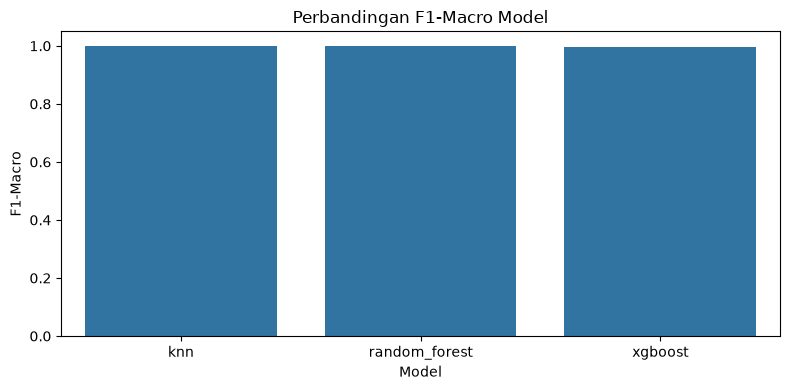

In [3]:
plt.figure(figsize=(8, 4))
sns.barplot(data=comparison, x='model', y='f1_macro')
plt.ylim(0, 1.05)
plt.title('Perbandingan F1-Macro Model')
plt.xlabel('Model')
plt.ylabel('F1-Macro')
plt.tight_layout()
plt.show()

In [4]:
artifact = joblib.load(MODEL_PATH)
print('Model terbaik:', artifact['model_name'])
artifact['comparison']

Model terbaik: knn


,model,accuracy,f1_macro,best_params
0,knn,1.000,1.000000,"{'n_neighbors': 5, 'weights': 'distance'}"
1,random_forest,1.000,1.000000,"{'max_depth': None, 'n_estimators': 100}"
2,xgboost,0.995,0.994999,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti..."


## Evaluasi Model Terbaik

Evaluasi dilakukan dengan script:

```powershell
python -m src.evaluate_model
```

Output evaluasi disimpan pada folder `reports/evaluation/`.

In [5]:
report = pd.read_csv(REPORT_PATH, index_col=0)
report

,precision,recall,f1-score,support
idle,1.0,1.0,1.0,40.0
right_arrow_left,1.0,1.0,1.0,40.0
right_arrow_right,1.0,1.0,1.0,40.0
right_click,1.0,1.0,1.0,40.0
right_cursor,1.0,1.0,1.0,40.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,200.0
weighted avg,1.0,1.0,1.0,200.0


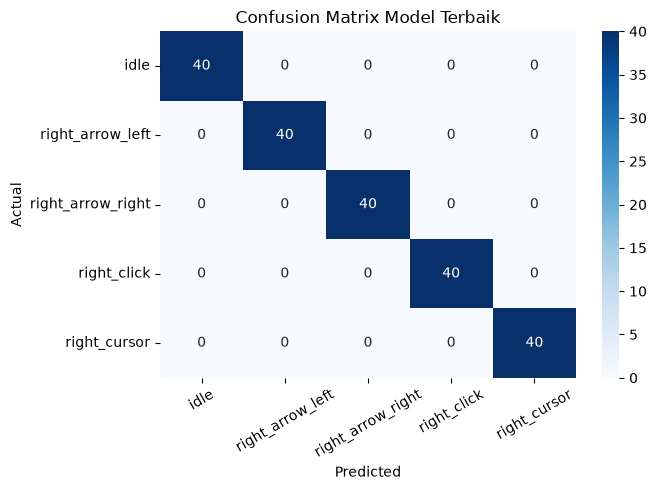

In [6]:
model = artifact['model']
label_encoder = artifact['label_encoder']
x_test = artifact['x_test']
y_test = artifact['y_test']
y_pred = model.predict(x_test)

matrix = confusion_matrix(y_test, y_pred)
labels = label_encoder.classes_
plt.figure(figsize=(7, 5))
sns.heatmap(matrix, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.title('Confusion Matrix Model Terbaik')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=30)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Interpretasi Hasil

Berdasarkan hasil training saat ini, KNN dan Random Forest mencapai accuracy dan F1-macro 1.0 pada validation set, sedangkan XGBoost mencapai F1-macro sekitar 0.995. Model terbaik yang tersimpan adalah KNN. Hasil classification report pada test set juga menunjukkan nilai precision, recall, dan F1-score yang sangat tinggi untuk semua kelas.

Kemungkinan alasan performa tinggi adalah dataset gesture memiliki pola landmark yang cukup jelas dan kelas relatif seimbang. Namun, model tetap perlu diuji pada kondisi nyata yang lebih bervariasi, misalnya pencahayaan berbeda, jarak tangan berbeda, dan pengguna berbeda.

## Kesimpulan Modeling

- Minimal dua model sudah diuji: KNN, Random Forest, dan XGBoost.
- Hyperparameter tuning dilakukan menggunakan Grid Search.
- Metrik utama adalah F1-macro.
- Model terbaik disimpan sebagai `models/best_model.joblib`.
- Hasil evaluasi disimpan ke `reports/evaluation/`.